In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

import joblib

df = pd.read_csv(
    "../datasets/cleaned/startup_info.csv",
    low_memory=False
)

print(df.shape)

df.head()

(50000, 155)


,startup_name,city,state,country,sector,sub_sector,founded_year,startup_stage,funding_stage,total_funding,...,description_quality_score,business_clarity_score,innovation_text_score,market_fit_score,investor_appeal_score,description_analyzer_score,market_gap_score,market_gap_label,startup_cluster,cluster_name
0,HyperAnalytics Technologies,Mumbai,Tamil Nadu,India,EdTech,Fleet Management,2016,Series B,Series D,6805013,...,80,75,20,45,45,56.25,51.562123,Medium Opportunity,3,High Risk
1,HealthConnect Solutions,Mumbai,Karnataka,India,EdTech,Telemedicine,2017,Series B,Series C,2213939,...,80,75,20,45,45,56.25,39.830587,Low Opportunity,3,High Risk
2,InsightLoop Ventures,Bangalore,Delhi,India,HealthTech,Generative AI,2003,MVP,IPO,9692982,...,80,75,40,45,45,60.25,34.798183,Low Opportunity,3,High Risk
3,BioHub Analytics,Pune,Delhi,India,Gaming,Telemedicine,2023,Idea,Series B,1326080,...,80,75,40,45,45,60.25,41.101654,Medium Opportunity,3,High Risk
4,WaveGen Private Limited,Delhi,Tamil Nadu,India,EdTech,General Technology,2018,Seed,Series C,6850202,...,80,75,0,45,45,52.25,33.536952,Low Opportunity,3,High Risk


In [6]:
df["success_probability_label"] = pd.cut(

    df["startup_health_score"],

    bins=[0, 35, 55, 100],

    labels=[
        "Low",
        "Medium",
        "High"
    ]

)

print(
    df["success_probability_label"]
    .value_counts()
)

success_probability_label
Medium    39180
Low        7089
High       3731
Name: count, dtype: int64


In [7]:
le = LabelEncoder()

df["success_probability_label_encoded"] = (

    le.fit_transform(
        df["success_probability_label"]
    )

)

print(
    dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
)

{'High': 0, 'Low': 1, 'Medium': 2}


In [8]:
features = [

    "startup_age",

    "founder_strength_score",

    "funding_strength_score",

    "market_opportunity_score",

    "growth_score",

    "employee_count",

    "investor_count",

    "total_funding",

    "market_size",

    "revenue",

    "retention_rate",

    "customer_count"

]

X = df[features]

y = df[
    "success_probability_label_encoded"
]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(40000, 12)
(10000, 12)


In [10]:
model = RandomForestClassifier(

    n_estimators=300,

    max_depth=12,

    random_state=42,

    n_jobs=-1

)

model.fit(
    X_train,
    y_train
)

print("Training Complete ✅")

Training Complete ✅


In [11]:
y_pred = model.predict(
    X_test
)

In [12]:
acc = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(acc * 100,2),
    "%"
)

Accuracy: 93.84 %


In [13]:
print(

    classification_report(

        y_test,

        y_pred,

        target_names=le.classes_

    )

)

              precision    recall  f1-score   support

        High       1.00      0.59      0.74       746
         Low       0.99      0.79      0.88      1418
      Medium       0.93      1.00      0.96      7836

    accuracy                           0.94     10000
   macro avg       0.97      0.79      0.86     10000
weighted avg       0.94      0.94      0.93     10000



In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 437    0  309]
 [   0 1120  298]
 [   1    8 7827]]


In [15]:
importance = pd.DataFrame({

    "Feature": features,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print(importance)

                     Feature  Importance
1     founder_strength_score    0.287155
2     funding_strength_score    0.230735
4               growth_score    0.209759
3   market_opportunity_score    0.105844
6             investor_count    0.044170
10            retention_rate    0.024184
7              total_funding    0.018905
11            customer_count    0.018505
8                market_size    0.018332
9                    revenue    0.016712
5             employee_count    0.014917
0                startup_age    0.010783


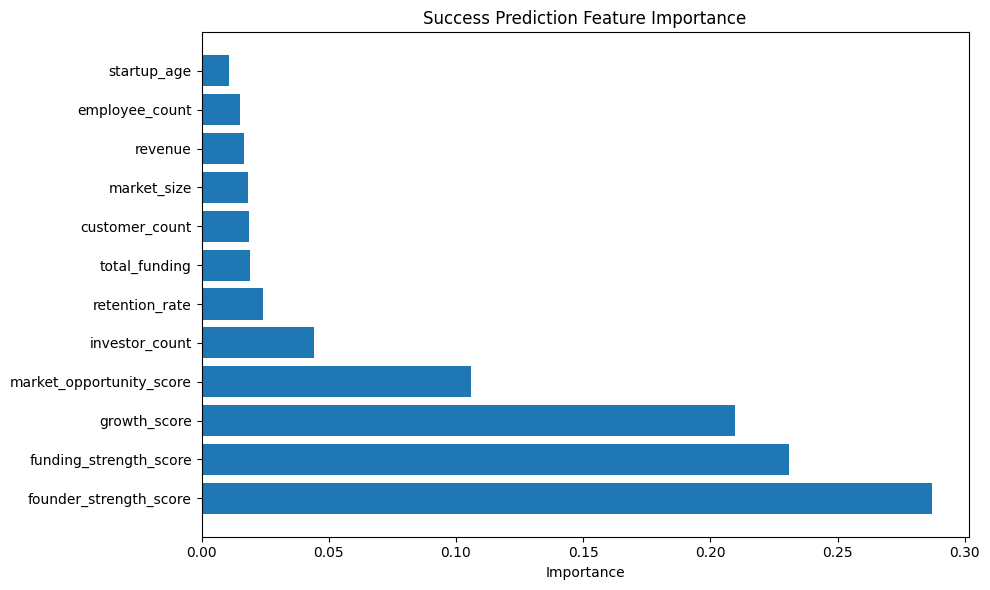

In [16]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title(
    "Success Prediction Feature Importance"
)

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [17]:
# joblib.dump(

#     model,

#     "../models/success_model/random_forest_success.pkl"

# )

# print("Model Saved ✅")

In [18]:
# joblib.dump(

#     le,

#     "../models/success_model/label_encoder.pkl"

# )

# print("Label Encoder Saved ✅")

In [19]:
import json

metadata = {

    "model_name":
        "Startup Success Prediction Model",

    "algorithm":
        "Random Forest Classifier",

    "target_column":
        "success_probability_label",

    "features":
        features,

    "classes":
        list(
            le.classes_
        ),

    "total_features":
        len(features),

    "train_samples":
        len(X_train),

    "test_samples":
        len(X_test),

    "accuracy":
        round(acc, 4)

}

with open(

    "../models/success_model/metadata.json",

    "w"

) as f:

    json.dump(

        metadata,

        f,

        indent=4

    )

print(
    "Metadata Saved Successfully ✅"
)

Metadata Saved Successfully ✅
